In [18]:
%reload_ext autoreload
%autoreload 2

## 1. Setup

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from types import SimpleNamespace

In [20]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

## 2. Material Models

### 2.1 Micro-scale Phases

In [21]:
from materials import NLElasticMatrix, LinearElastic

# Shared material parameters
Km, alpha1, alpha2 = 4780.0, 50.0, 0.06     # Soft matrix (NLElasticMatrix)
Kf, Gf             = 43500.0, 29900.0        # Hard inclusion (isotropic linear elastic)

E_hard  = (9.0 * Kf * Gf) / (3.0 * Kf + Gf)
nu_hard = (3.0 * Kf - 2.0 * Gf) / (2.0 * (3.0 * Kf + Gf))

soft = NLElasticMatrix(Km=Km, alpha1=alpha1, alpha2=alpha2)
hard = LinearElastic(emod=E_hard, nu=nu_hard)

print(f"Soft:  NLElasticMatrix  Km={Km}, alpha1={alpha1}, alpha2={alpha2}")
print(f"Hard:  LinearElastic    E={E_hard:.1f}, nu={nu_hard:.4f}")

Soft:  NLElasticMatrix  Km=4780.0, alpha1=50.0, alpha2=0.06
Hard:  LinearElastic    E=72979.1, nu=0.2204


### 2.2 Microstructure Pool

In [22]:
from microstructures import RandomBlocks, MicrostructurePool

# Microstructure parameters
fhard_min, fhard_max, nbins = 0.40, 0.40, 1
fhard_bins = torch.linspace(fhard_min, fhard_max, nbins)
rve_lx, rve_ly = 0.10, 0.10

# Shared microstructure pool — FNO and FEM² use the same object (same seed, same nmicro)
pool = MicrostructurePool(
    generator=RandomBlocks(resolution=96, n_blocks=8),
    fhard_bins=fhard_bins,
    nmicro=1,
    meshing=True,
    delta_x=rve_lx,
    delta_y=rve_ly,
    device='cpu',
    dtype=torch.float32,
)

Building MicrostructurePool: 1 bins × 1 variants = 1 microstructures...
   →   1/1 microstructures generated
MicrostructurePool ready | Shape: torch.Size([1, 1, 96, 96])


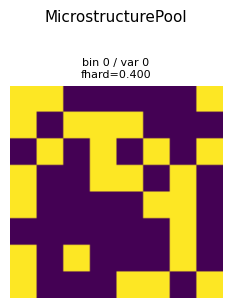

In [23]:
pool.plot(max_cols=4)

### 2.2 FNO Surrogate

In [24]:

def fhard_constant(coords):
    """Constant value: fhard_max everywhere."""
    return torch.full_like(coords[..., 0], fhard_max)

In [25]:
from rve_analyzer import load_trained_model
from materials import FNOmat

# Load trained surrogate model
model, normalizers = load_trained_model(
    checkpoint_dir="../RVEs/checkpoints", model_name_prefix="rve2_fno_v10"
)
model.to(device)

# FNO material
rve2_fno = FNOmat(
    model=model,
    normalizers=normalizers,
    microstructure_pool=pool,
    fhard=fhard_constant,
    chunk_size=64,
    dtype=torch.float32,
    device=device,
    seed=42,
)
print(f"FNOmat ready | device: {device}")

FNOmat ready | device: cuda


### 2.3 Analytical Homogenization (ROM)

In [26]:
from materials import ROMmat

f_hard, f_soft = 0.40, 0.60

rve2_voigt = ROMmat(
    soft,
    hard,
    fraction_1=f_soft,
    method='voigt',
)
rve2_reuss = ROMmat(
    soft,
    hard,
    fraction_1=f_soft,
    method='reuss',
)
print(f"Voigt (upper bound) and Reuss (lower bound) ready | f_hard={f_hard}")

Voigt (upper bound) and Reuss (lower bound) ready | f_hard=0.4


### 2.4 FEM² Full-field Homogenization

In [27]:
from materials import FEMmat

# FEM pool reuses pool (same microstructures as FNO)
nelem_rve = pool.pool_phase.shape[2] // 2   # 96/2 = 48 elements per side
print(f"FEM pool: {pool.num_bins} bins × {pool.nmicro} variants "
      f"= {len(pool.meshes)} meshes  |  RVE: {nelem_rve}×{nelem_rve} Q4  "
      f"({rve_lx}×{rve_ly})")

FEM pool: 1 bins × 1 variants = 1 meshes  |  RVE: 48×48 Q4  (0.1×0.1)


In [28]:
rve2_fem = FEMmat(
    soft=NLElasticMatrix(Km=Km, alpha1=alpha1, alpha2=alpha2,
                         dtype=torch.float64, device='cpu'),
    hard=LinearElastic(emod=E_hard, nu=nu_hard,
                       dtype=torch.float64, device='cpu'),
    microstructure_pool=pool,
    fhard=fhard_constant,
    n_state=3,
    dtype=torch.float64,
    device='cpu',
    exact_integration=False,   # uniform voxelized mesh -> mean is exact
    fd_scheme='central',
    seed=42,
)
print(f"FEMmat ready | RVE: {nelem_rve}×{nelem_rve} Q4 ({rve_lx}×{rve_ly}) | "
      f"fd_scheme='{rve2_fem.fd_scheme}'")

FEMmat ready | RVE: 48×48 Q4 (0.1×0.1) | fd_scheme='central'


## 3. Evaluation Functions

In [29]:
def von_mises_2d(stress):
    """Von Mises equivalent stress for 2D plane strain Voigt vector [sxx, syy, sxy]."""
    sxx, syy, sxy = stress[..., 0], stress[..., 1], stress[..., 2]
    return torch.sqrt(sxx**2 + syy**2 - sxx * syy + 3.0 * sxy**2)


def evaluate_material(material, strain_path, dtype=torch.float64, device='cpu'):
    """
    Evaluate a material along a strain path.

    Returns dict with 'sigma_eq', 'C11', 'C22', 'C33' (nsteps,) arrays,
    plus 'stress_last' (3,) and 'tangent_last' (3,3) at the final step.
    """
    nsteps = strain_path.shape[0]
    sigma_eq = np.zeros(nsteps)
    C11 = np.zeros(nsteps)
    C22 = np.zeros(nsteps)
    C33 = np.zeros(nsteps)

    coords = torch.zeros(1, 1, 2, dtype=dtype, device=device)
    state = material.init_state(1, 1, coords=coords)

    stress_last = np.zeros(3)
    tangent_last = np.zeros((3, 3))

    for i in range(nsteps):
        eps = strain_path[i].to(dtype=dtype, device=device).reshape(1, 1, 3)
        stress, state_new, ddsdde = material.update_state(eps, state, isTangent=True)

        sigma_eq[i] = von_mises_2d(stress).item()
        if ddsdde is not None:
            C11[i] = ddsdde[0, 0, 0, 0].item()
            C22[i] = ddsdde[0, 0, 1, 1].item()
            C33[i] = ddsdde[0, 0, 2, 2].item()

        if i == nsteps - 1:
            stress_last = stress[0, 0].detach().cpu().numpy()
            if ddsdde is not None:
                tangent_last = ddsdde[0, 0].detach().cpu().numpy()

    return {
        'sigma_eq': sigma_eq, 'C11': C11, 'C22': C22, 'C33': C33,
        'stress_last': stress_last, 'tangent_last': tangent_last,
    }


def evaluate_all_models(strain_path, models_dict):
    """Evaluate all models along a strain path."""
    results = {}
    for name, (mat, dt, dev) in models_dict.items():
        t0 = time.time()
        results[name] = evaluate_material(mat, strain_path, dtype=dt, device=dev)
        elapsed = time.time() - t0
        print(f"  {name:12s}: {elapsed:6.1f}s")
    return results


def print_fem_fno_comparison(results, strain_last):
    """Print stress components, von Mises, and tangent for FEM vs FNO at the last strain step."""
    print(f"{'':20s} {'FEM':>14s} {'FNO':>14s} {'Error (%)':>12s}")
    print("-" * 62)

    # Stress components
    labels = [r'σ_xx', r'σ_yy', r'σ_xy', r'σ_eq']
    fem_vals = list(results['FEM']['stress_last']) + [results['FEM']['sigma_eq'][-1]]
    fno_vals = list(results['FNO']['stress_last']) + [results['FNO']['sigma_eq'][-1]]

    for lbl, fem_v, fno_v in zip(labels, fem_vals, fno_vals):
        err = abs(fno_v - fem_v) / max(abs(fem_v), 1e-15) * 100
        print(f"  {lbl:18s} {fem_v:14.6f} {fno_v:14.6f} {err:11.2f}%")

    print()
    print(f"  Consistent tangent (last step, ε = {strain_last:.4f}):")
    print(f"  {'FEM':>42s}")
    C_fem = results['FEM']['tangent_last']
    for row in range(3):
        print(f"  [{C_fem[row, 0]:12.2f} {C_fem[row, 1]:12.2f} {C_fem[row, 2]:12.2f} ]")

    print(f"\n  {'FNO':>42s}")
    C_fno = results['FNO']['tangent_last']
    for row in range(3):
        print(f"  [{C_fno[row, 0]:12.2f} {C_fno[row, 1]:12.2f} {C_fno[row, 2]:12.2f} ]")

    print(f"\n  {'Relative error (%)':>42s}")
    for row in range(3):
        errs = [abs(C_fno[row, c] - C_fem[row, c]) / max(abs(C_fem[row, c]), 1e-15) * 100
                for c in range(3)]
        print(f"  [{errs[0]:11.2f}% {errs[1]:11.2f}% {errs[2]:11.2f}% ]")

In [30]:
MODEL_STYLES = {
    'Fiber (hard)': dict(color='tab:gray',   ls='-',  lw=1.5, marker=None),
    'Voigt':        dict(color='tab:blue',   ls='-',  lw=2.0, marker=None),
    'FEM':          dict(color='black',      ls='none',lw=0,   marker='o', ms=4),
    'FNO':          dict(color='tab:red',    ls='--', lw=2.0, marker=None),
    'Reuss':        dict(color='tab:green',  ls='-',  lw=2.0, marker=None),
    'Matrix (soft)':dict(color='tab:orange', ls='-',  lw=1.5, marker=None),
}


def plot_case(t_vals, results, case_title, quantities=None):
    """
    Plot 4 separate figures for a load case.

    Parameters
    ----------
    t_vals : array (nsteps,)
        Loading parameter values for x-axis.
    results : dict {model_name: {quantity: array}}
    case_title : str
        Title prefix for each figure.
    quantities : list of (key, label) pairs. Defaults to sigma_eq, C11, C22, C33.
    """
    if quantities is None:
        quantities = [
            ('sigma_eq', r'$\bar{\sigma}_{eq}$ (von Mises)'),
            ('C11', r'$C_{11}$'),
            ('C22', r'$C_{22}$'),
            ('C33', r'$C_{33}$'),
        ]

    for qkey, qlabel in quantities:
        fig, ax = plt.subplots(figsize=(8, 5))

        # Get Voigt max for y-limit
        voigt_max = results['Voigt'][qkey].max() if 'Voigt' in results else None

        for name in MODEL_STYLES:
            if name not in results:
                continue
            style = MODEL_STYLES[name]
            y = results[name][qkey]
            ax.plot(t_vals, y,
                    color=style['color'], ls=style['ls'], lw=style['lw'],
                    marker=style.get('marker'), markersize=style.get('ms', 4),
                    label=name)

        if voigt_max is not None and voigt_max > 0:
            ax.set_ylim(bottom=0, top=voigt_max * 1.05)

        ax.set_xlim(t_vals[0], t_vals[-1])
        ax.set_xlabel(r'$t$ (loading parameter)')
        ax.set_ylabel(qlabel)
        ax.set_title(f'{case_title} — {qlabel}')
        ax.legend(loc='best', framealpha=0.9)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()

In [31]:
def build_strain_path(nsteps, exx=False, eyy=False, gxy=False, t_max=0.02):
    """
    Build a strain path tensor (nsteps, 3) in Voigt notation [exx, eyy, gxy].

    Parameters
    ----------
    nsteps : int
    exx, eyy, gxy : bool
        Which components vary with t.
    t_max : float

    Returns
    -------
    t_vals : numpy array (nsteps,)
    strain_path : Tensor (nsteps, 3)
    """
    t_vals = np.linspace(0, t_max, nsteps)
    strain = np.zeros((nsteps, 3))
    if exx: strain[:, 0] = t_vals
    if eyy: strain[:, 1] = t_vals
    if gxy: strain[:, 2] = t_vals
    return t_vals, torch.from_numpy(strain)


# Models dictionary: {display_name: (material, dtype, device)}
models = {
    'Fiber (hard)': (hard,        torch.float64, 'cpu'),
    'Voigt':        (rve2_voigt,  torch.float64, 'cpu'),
    'FEM':          (rve2_fem,    torch.float64, 'cpu'),
    'FNO':          (rve2_fno,    torch.float32, device),
    'Reuss':        (rve2_reuss,  torch.float64, 'cpu'),
    'Matrix (soft)':(soft,        torch.float64, 'cpu'),
}

NSTEPS = 50

## 4. Case 1 — Uniaxial Traction

$$\varepsilon_{xx} = t \in [0, 0.02], \quad \varepsilon_{yy} = 0, \quad \gamma_{xy} = 0$$

Case 1 — Uniaxial Traction
  Fiber (hard):    0.0s
  Voigt       :    0.0s
  FEM         :  646.7s
  FNO         :    1.1s
  Reuss       :    0.1s
  Matrix (soft):    0.0s

=== FEM vs FNO comparison (last step) ===
                                FEM            FNO    Error (%)
--------------------------------------------------------------
  σ_xx                   214.616394     214.409500        0.10%
  σ_yy                   166.741628     164.366272        1.42%
  σ_xy                   -14.896944     -14.002084        6.01%
  σ_eq                   196.833018     195.791183        0.53%

  Consistent tangent (last step, ε = 0.0200):
                                         FEM
  [    10113.86      8454.76      -698.68 ]
  [     8454.76     11460.04      -793.49 ]
  [     -698.68      -793.49      1656.67 ]

                                         FNO
  [    10176.77      8333.36      -658.37 ]
  [     8333.36     11374.38      -715.28 ]
  [     -658.37      -715.28      1616.30 ]


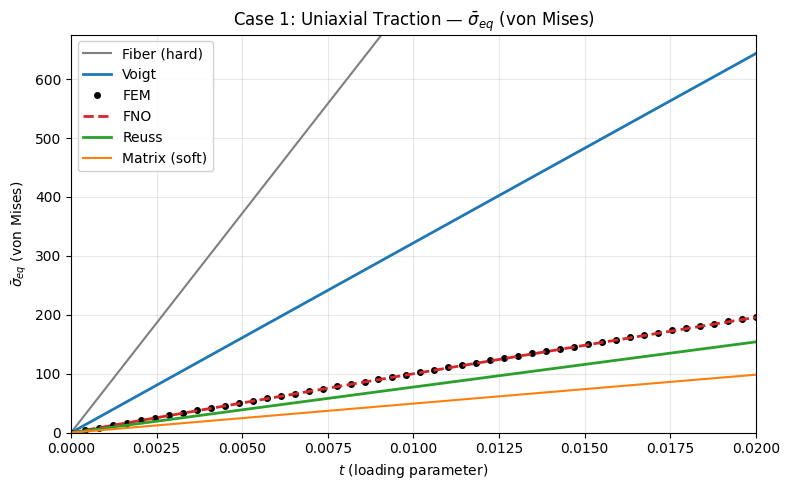

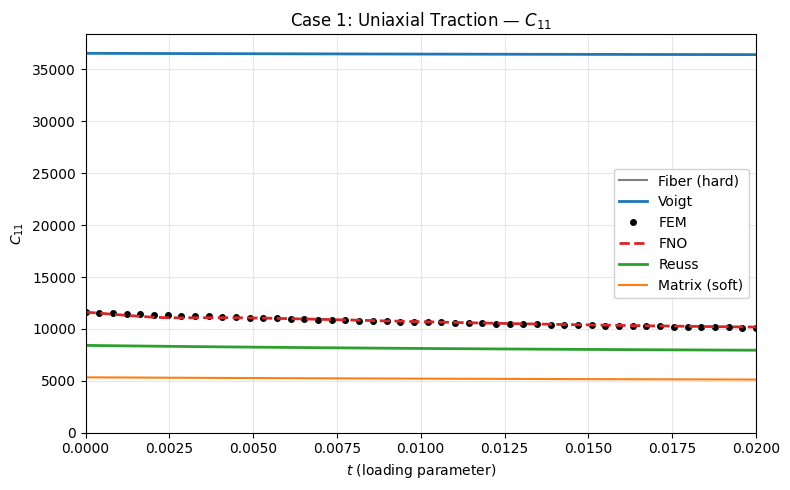

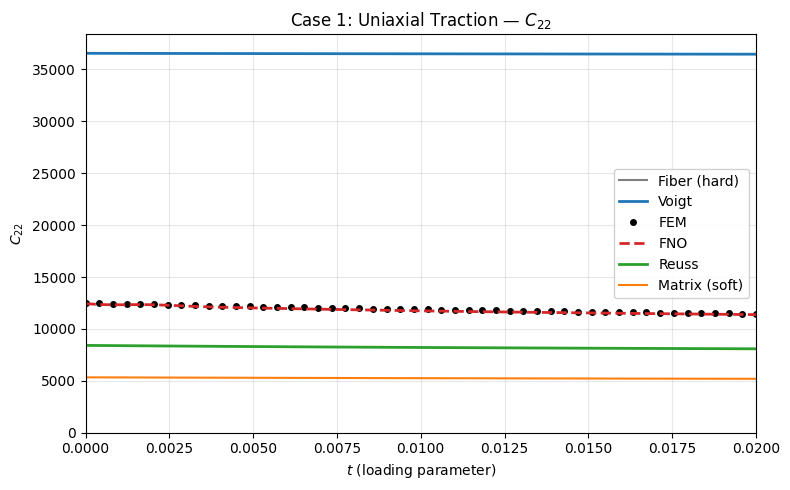

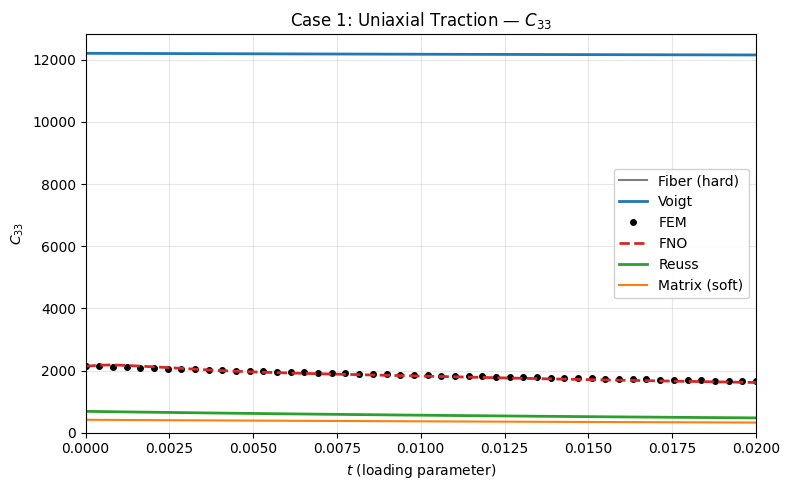

In [32]:
t_vals_1, strain_path_1 = build_strain_path(NSTEPS, exx=True)

print("Case 1 — Uniaxial Traction")
results_1 = evaluate_all_models(strain_path_1, models)

print("\n=== FEM vs FNO comparison (last step) ===")
print_fem_fno_comparison(results_1, t_vals_1[-1])

plot_case(t_vals_1, results_1, "Case 1: Uniaxial Traction")

## 5. Case 2 — Biaxial Traction

$$\varepsilon_{xx} = \varepsilon_{yy} = t \in [0, 0.02], \quad \gamma_{xy} = 0$$

Case 2 — Biaxial Traction
  Fiber (hard):    0.0s
  Voigt       :    0.0s
  FEM         :  943.6s
  FNO         :    1.9s
  Reuss       :    0.1s
  Matrix (soft):    0.0s

=== FEM vs FNO comparison (last step) ===
                                FEM            FNO    Error (%)
--------------------------------------------------------------
  σ_xx                   378.289068     375.172119        0.82%
  σ_yy                   392.138791     386.957886        1.32%
  σ_xy                   -29.801957     -25.592916       14.12%
  σ_eq                   388.842002     383.770386        1.30%

  Consistent tangent (last step, ε = 0.0200):
                                         FEM
  [    10254.28      8045.88      -683.04 ]
  [     8045.88     10864.46      -724.24 ]
  [     -683.04      -724.24      1525.78 ]

                                         FNO
  [    10407.20      8026.34      -639.03 ]
  [     8026.34     10730.03      -575.43 ]
  [     -639.03      -575.43      1405.08 ]



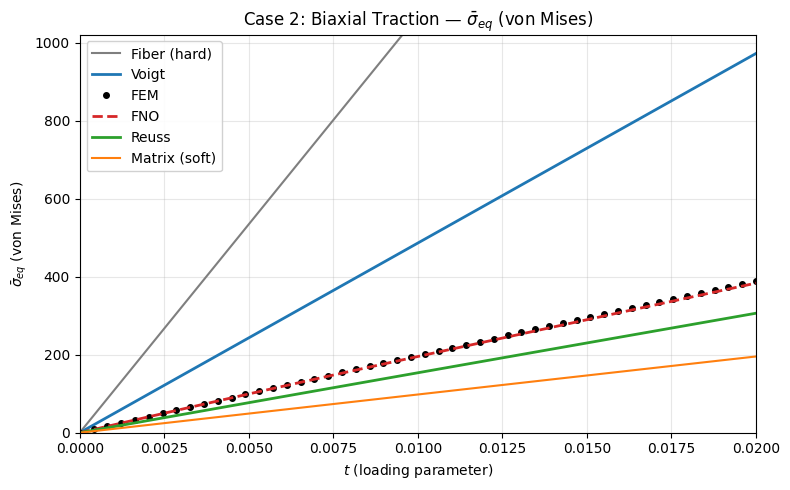

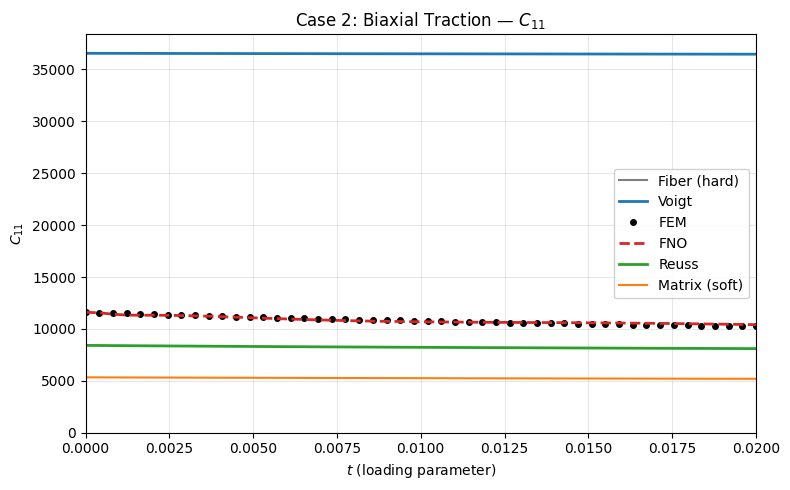

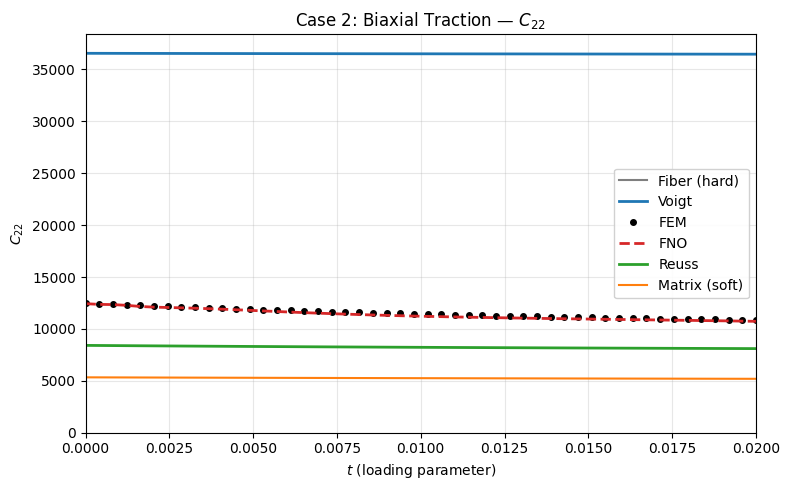

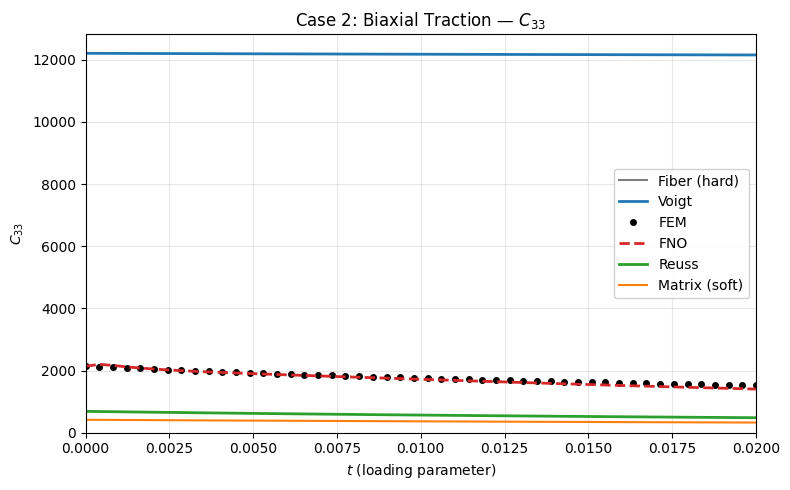

In [33]:
t_vals_2, strain_path_2 = build_strain_path(NSTEPS, exx=True, eyy=True)

print("Case 2 — Biaxial Traction")
results_2 = evaluate_all_models(strain_path_2, models)

print("\n=== FEM vs FNO comparison (last step) ===")
print_fem_fno_comparison(results_2, t_vals_2[-1])

plot_case(t_vals_2, results_2, "Case 2: Biaxial Traction")

## 6. Case 3 — Uniaxial Traction with Shear

$$\varepsilon_{xx} = \gamma_{xy} = t \in [0, 0.02], \quad \varepsilon_{yy} = 0$$

Case 3 — Uniaxial Traction with Shear
  Fiber (hard):    0.0s
  Voigt       :    0.0s
  FEM         : 3761.6s
  FNO         :    1.1s
  Reuss       :    0.1s
  Matrix (soft):    0.0s

=== FEM vs FNO comparison (last step) ===
                                FEM            FNO    Error (%)
--------------------------------------------------------------
  σ_xx                   197.959667     196.890625        0.54%
  σ_yy                   150.715191     149.879654        0.55%
  σ_xy                    18.649776      17.213789        7.70%
  σ_eq                   181.964315     180.579269        0.76%

  Consistent tangent (last step, ε = 0.0200):
                                         FEM
  [    10220.72      8409.84      -891.94 ]
  [     8409.84     11428.41      -782.87 ]
  [     -891.94      -782.87      1582.99 ]

                                         FNO
  [    10466.95      8421.25      -910.27 ]
  [     8421.25     11265.47      -702.72 ]
  [     -910.27      -702.72     

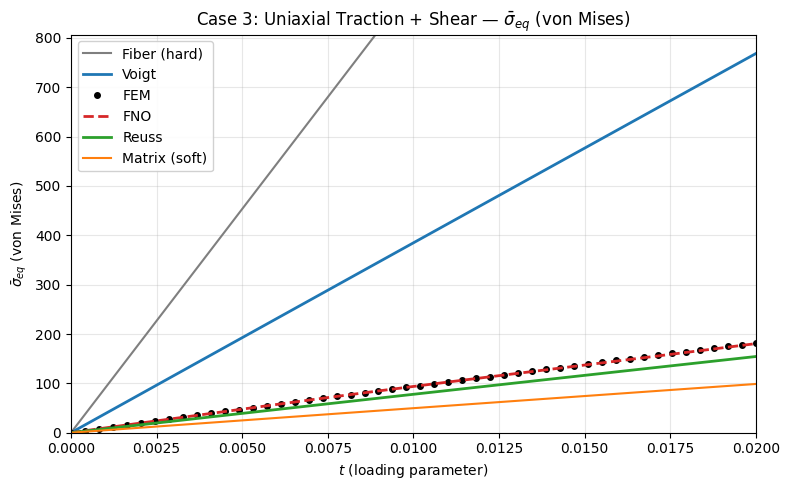

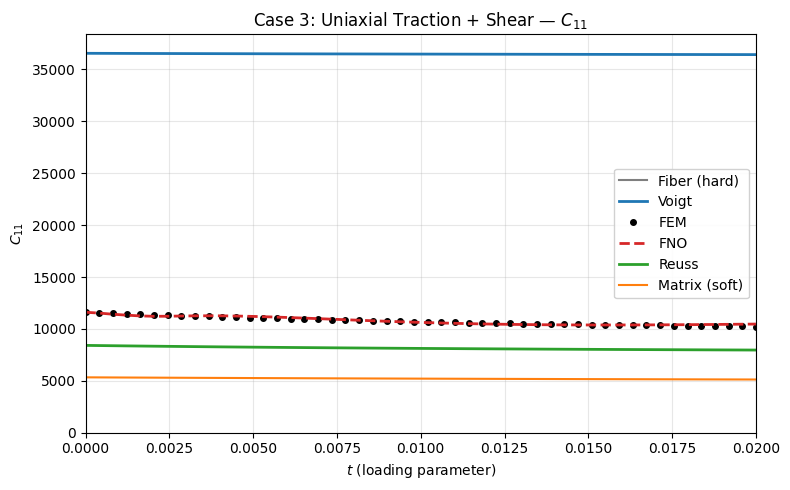

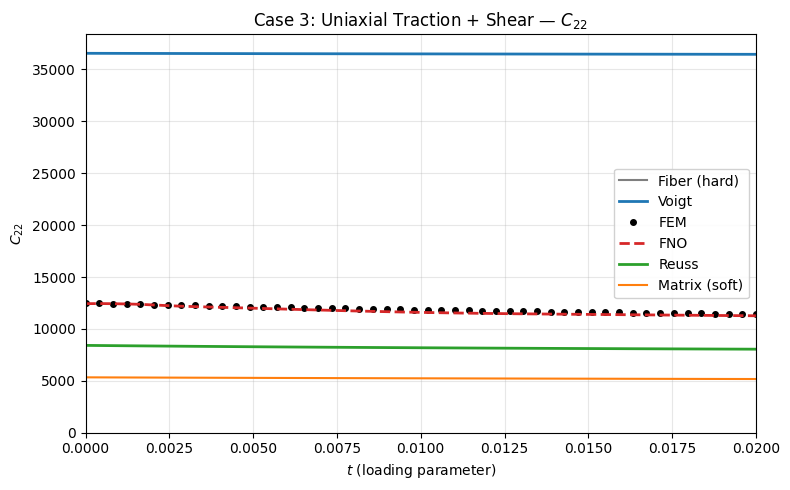

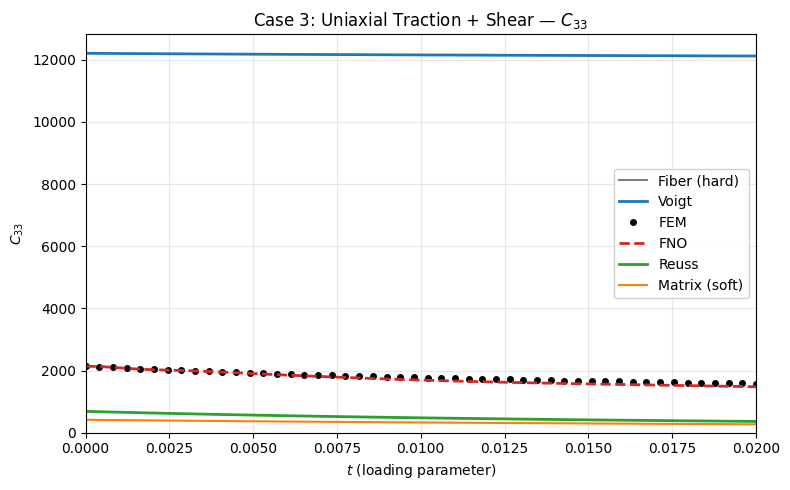

In [34]:
t_vals_3, strain_path_3 = build_strain_path(NSTEPS, exx=True, gxy=True)

print("Case 3 — Uniaxial Traction with Shear")
results_3 = evaluate_all_models(strain_path_3, models)

print("\n=== FEM vs FNO comparison (last step) ===")
print_fem_fno_comparison(results_3, t_vals_3[-1])

plot_case(t_vals_3, results_3, "Case 3: Uniaxial Traction + Shear")

## 7. Case 4 — Biaxial Traction with Shear

$$\varepsilon_{xx} = \varepsilon_{yy} = \gamma_{xy} = t \in [0, 0.02]$$

Case 4 — Biaxial Traction with Shear
  Fiber (hard):    0.0s
  Voigt       :    0.0s
  FEM         :  503.8s
  FNO         :    1.2s
  Reuss       :    0.1s
  Matrix (soft):    0.0s

=== FEM vs FNO comparison (last step) ===
                                FEM            FNO    Error (%)
--------------------------------------------------------------
  σ_xx                   362.931855     362.844574        0.02%
  σ_yy                   375.826077     373.347198        0.66%
  σ_xy                     1.220710       2.176821       78.32%
  σ_eq                   369.553767     368.227539        0.36%

  Consistent tangent (last step, ε = 0.0200):
                                         FEM
  [    10302.12      8147.81      -826.06 ]
  [     8147.81     10900.96      -898.39 ]
  [     -826.06      -898.39      1528.50 ]

                                         FNO
  [    10429.79      8164.78      -611.26 ]
  [     8164.78     10459.15      -640.94 ]
  [     -611.26      -640.94      

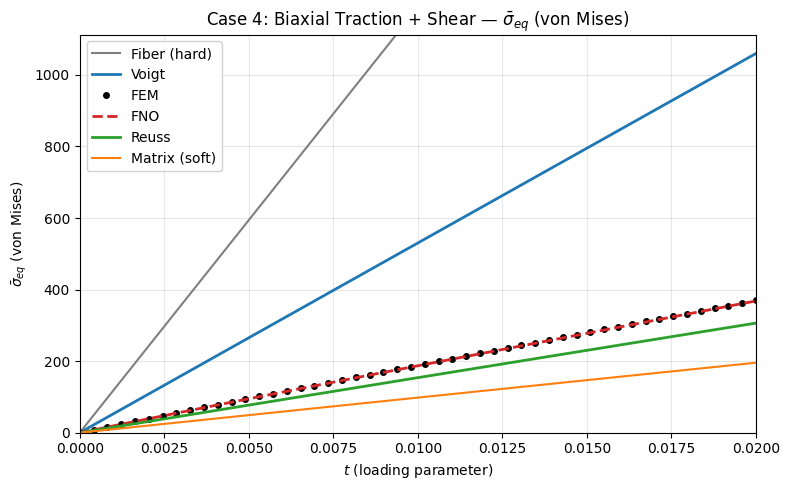

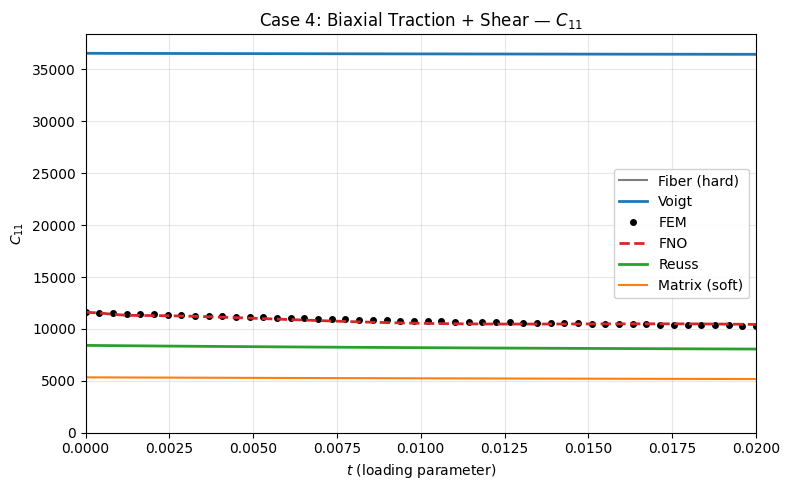

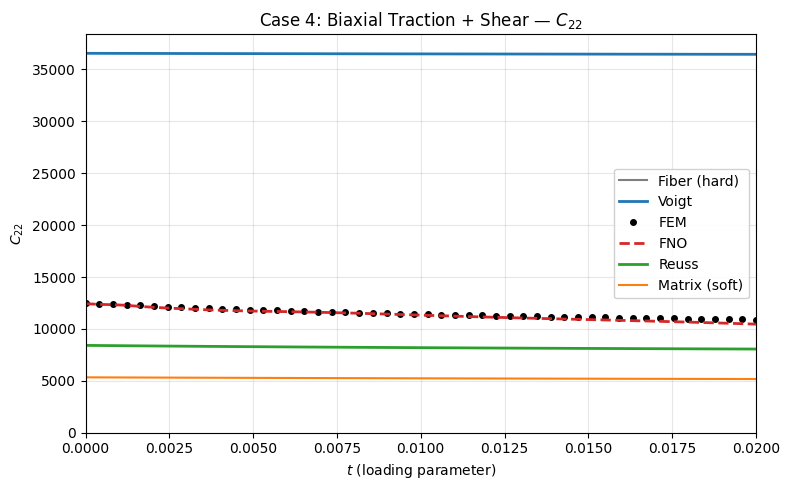

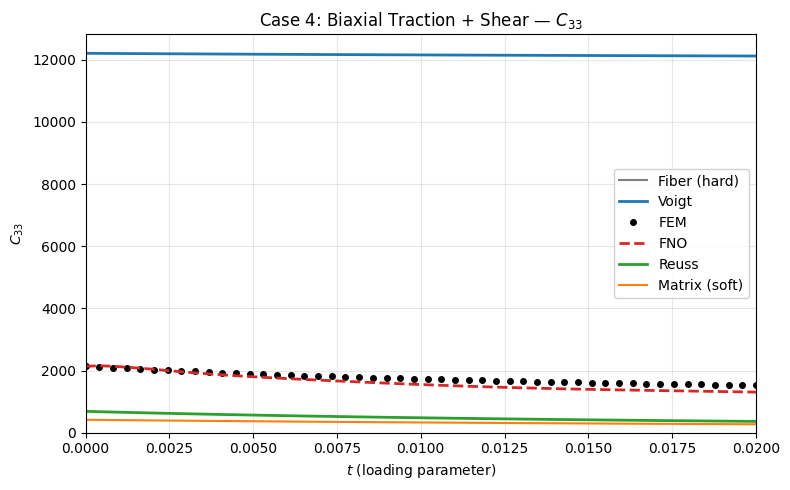

In [35]:
t_vals_4, strain_path_4 = build_strain_path(NSTEPS, exx=True, eyy=True, gxy=True)

print("Case 4 — Biaxial Traction with Shear")
results_4 = evaluate_all_models(strain_path_4, models)

print("\n=== FEM vs FNO comparison (last step) ===")
print_fem_fno_comparison(results_4, t_vals_4[-1])

plot_case(t_vals_4, results_4, "Case 4: Biaxial Traction + Shear")